<div style="
    background-color: #01262bff;
    color: #ffffff;
    padding: 50px;
    border-radius: 10px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    text-align: center;
">
    
    <hr style="
        width: 50%;
        border: 1px solid #218b84ff;
        margin: 20px auto;
    ">
    <h2 style="
        font-size: 1.8em;
        font-weight: normal;
        color: #c3cfceff;
        margin-top: 10px;
    ">
        Author: <span style="font-weight: 600; color: #ffffff;">Shubham Adate</span>
    </h2>
</div>


# Product Clustering Analysis for Retail and Warehouse Sales

## Project Objective
The objective of this project is to identify meaningful product clusters based on their sales behavior across retail and warehouse channels. By applying clustering techniques, we aim to segment products with similar demand patterns to improve inventory management and strategic decision-making.

## Business Problem
Retail distributors manage thousands of products with varying demand patterns. Without segmentation, it becomes difficult to identify:

• fast-moving products  
• slow-moving inventory  
• warehouse-dominant products  
• redistribution-heavy items  

Product clustering helps businesses group similar products and make data-driven decisions related to inventory, purchasing, and distribution strategies.

In [2]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from kneed import KneeLocator

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

The dataset contains retail and warehouse sales information for various products.

Key variables include:
- Retail Sales
- Warehouse Sales
- Retail Transfers
- Supplier
- Item Type

In [11]:
df = pd.read_excel("data/Warehouse_and_Retail_Sales.xlsx")

df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


## Dataset Overview

Understanding the structure of the dataset including:
- Number of rows and columns
- Data types
- Missing values

In [12]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

___

## Data Cleaning

Data cleaning ensures that the dataset is consistent and ready for analysis. The following steps are performed:

• Removing duplicate records  
• Standardizing column names  
• Handling missing values  

In [13]:
df = df.drop_duplicates()

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

## Feature Engineering

Instead of clustering raw data, we create meaningful features that represent product sales behavior.

New features created:
- Total Sales
- Retail Sales Ratio
- Warehouse Sales Ratio
- Transfer Ratio

In [14]:
df['total_sales'] = df['retail_sales'] + df['warehouse_sales']

df['retail_ratio'] = df['retail_sales'] / df['total_sales']
df['warehouse_ratio'] = df['warehouse_sales'] / df['total_sales']
df['transfer_ratio'] = df['retail_transfers'] / df['total_sales']

df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

## Aggregating Data at Product Level

Clustering should be performed at the product level rather than transaction level.

We aggregate sales statistics for each product.

In [15]:
product_df = df.groupby(['item_code','item_type','supplier']).agg({
    
    'retail_sales':'sum',
    'warehouse_sales':'sum',
    'retail_transfers':'sum',
    'total_sales':'sum',
    'retail_ratio':'mean',
    'warehouse_ratio':'mean',
    'transfer_ratio':'mean'
    
}).reset_index()

product_df.head()

,item_code,item_type,supplier,retail_sales,warehouse_sales,retail_transfers,total_sales,retail_ratio,warehouse_ratio,transfer_ratio
0,2,NON-ALCOHOL,0,6934.0,0.0,0.0,6934.0,1.0,0.0,0.000000
1,3,NON-ALCOHOL,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,4,NON-ALCOHOL,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,102,STR_SUPPLIES,Default,5.4,0.0,0.0,5.4,1.0,0.0,0.000000
4,104,STR_SUPPLIES,Default,55.1,0.0,38.9,55.1,1.0,0.0,0.654658


## Selecting Features for Clustering

We select numerical variables that represent sales patterns.

In [16]:
features = product_df[['retail_sales',
                       'warehouse_sales',
                       'retail_transfers',
                       'total_sales',
                       'retail_ratio',
                       'warehouse_ratio',
                       'transfer_ratio']]

## Feature Scaling

Clustering algorithms are distance-based, therefore features must be scaled.

In [17]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

##  ELBOW METHOD
Determining Optimal Number of Clusters

The elbow method is used to determine the optimal number of clusters by measuring the within-cluster sum of squares (WCSS).

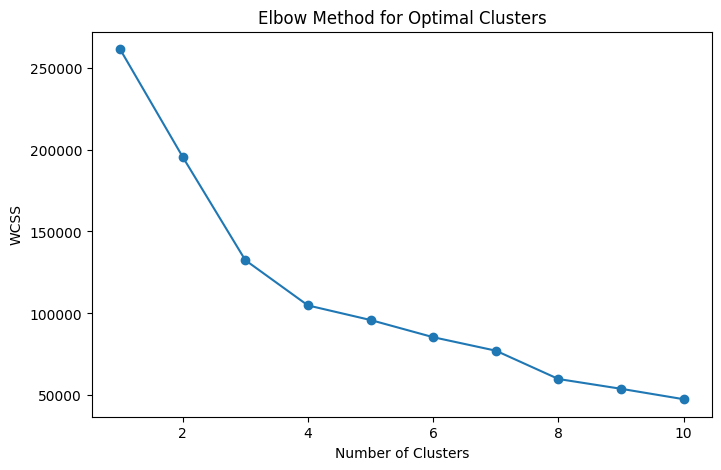

In [18]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Clusters")

plt.show()

## Finding Optimal Number of Clusters

We use the **Elbow Method** to determine the optimal number of clusters.

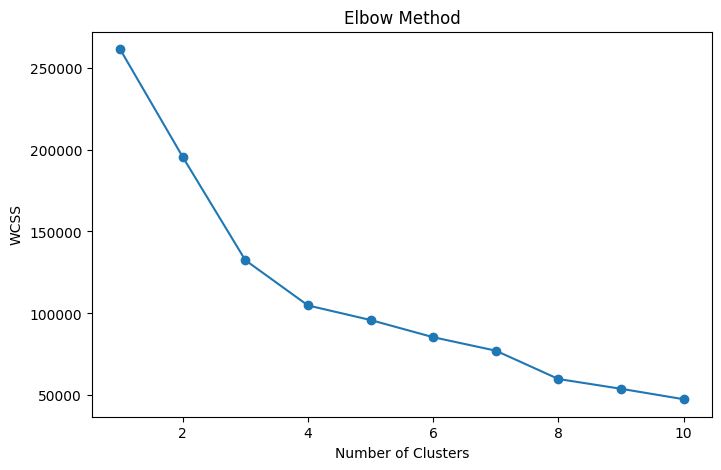

In [19]:
wcss = []

for k in range(1,11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

##  Optimal Cluster Detection

In [20]:
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')

optimal_k = kl.elbow

optimal_k

np.int64(4)

## Train Final KMeans Model

Choice of Clustering Algorithm

K-Means clustering was selected for this analysis due to its efficiency when working with large datasets and its ability to group observations based on similarity using distance-based metrics.
Since the objective of this project is to segment products based on their sales patterns, K-Means is well suited for identifying groups of products that exhibit similar retail and warehouse sales behavior.
Additionally, K-Means is computationally efficient and scalable, making it appropriate for datasets with a large number of observations such as the retail and warehouse sales dataset used in this analysis.

## Final Clustering Model

In [21]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

product_df['cluster'] = kmeans.fit_predict(scaled_df)

product_df.head()

,item_code,item_type,supplier,retail_sales,warehouse_sales,retail_transfers,total_sales,retail_ratio,warehouse_ratio,transfer_ratio,cluster
0,2,NON-ALCOHOL,0,6934.0,0.0,0.0,6934.0,1.0,0.0,0.000000,3
1,3,NON-ALCOHOL,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
2,4,NON-ALCOHOL,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
3,102,STR_SUPPLIES,Default,5.4,0.0,0.0,5.4,1.0,0.0,0.000000,0
4,104,STR_SUPPLIES,Default,55.1,0.0,38.9,55.1,1.0,0.0,0.654658,0


##  Cluster Evaluation

In [22]:
silhouette = silhouette_score(scaled_df, product_df['cluster'])

db_score = davies_bouldin_score(scaled_df, product_df['cluster'])

ch_score = calinski_harabasz_score(scaled_df, product_df['cluster'])

print("Silhouette Score:", silhouette)
print("Davies Bouldin Score:", db_score)
print("Calinski Harabasz Score:", ch_score)

Silhouette Score: 0.7639981430805682
Davies Bouldin Score: 0.7128797025751545
Calinski Harabasz Score: 18548.449752925844


##  PCA Visualization
 Cluster Visualization using PCA

In [23]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=['PC1','PC2'])

pca_df['cluster'] = product_df['cluster']

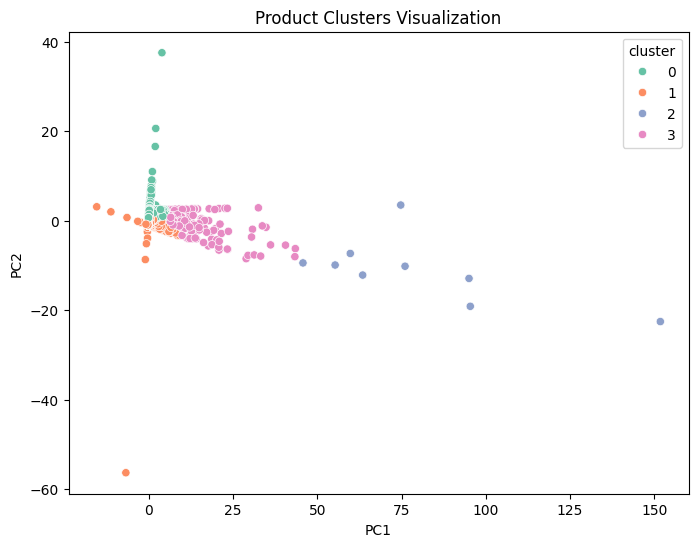

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df,
                x='PC1',
                y='PC2',
                hue='cluster',
                palette='Set2')

plt.title("Product Clusters Visualization")
plt.show()

### PCA Interpretation

The PCA visualization provides a two-dimensional representation of the clustered data, allowing us to observe how products are distributed across clusters.

The scatter plot shows that the clusters are reasonably separated, indicating that the clustering algorithm successfully identified distinct product segments based on their sales characteristics.

This visual separation supports the validity of the clustering results and suggests that the identified clusters represent meaningful differences in product sales behavior.

##  Cluster Analysis

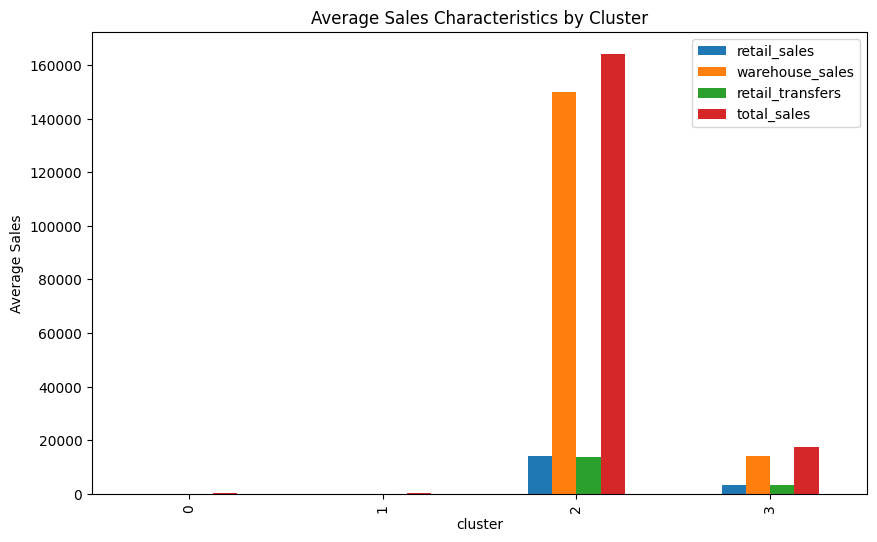

In [25]:
cluster_summary = product_df.groupby('cluster')[[
    'retail_sales',
    'warehouse_sales',
    'retail_transfers',
    'total_sales'
]].mean()

cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Average Sales Characteristics by Cluster")
plt.ylabel("Average Sales")
plt.show()

## Cluster Distribution

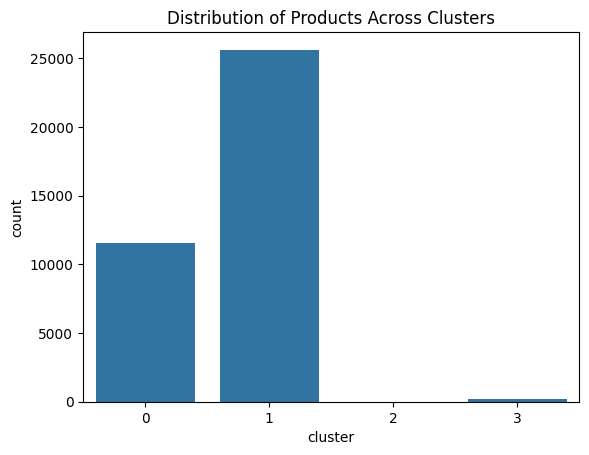

In [26]:
sns.countplot(x='cluster', data=product_df)

plt.title("Distribution of Products Across Clusters")

plt.show()

## Cluster vs Product Category

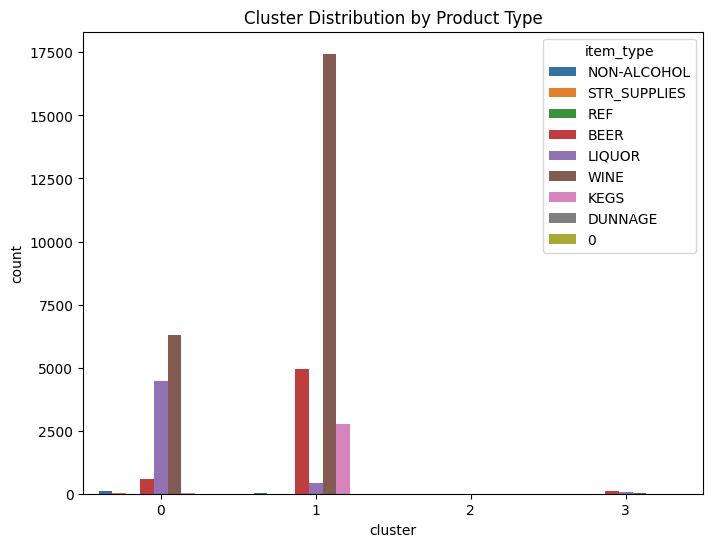

In [27]:
plt.figure(figsize=(8,6))

sns.countplot(data=product_df, x='cluster', hue='item_type')

plt.title("Cluster Distribution by Product Type")

plt.show()

___

##   Business Insights

Based on the clustering results, we can interpret product segments:

Cluster 0 – High Retail Demand  
Products in this cluster show strong retail sales and consistent demand.

Cluster 1 – Warehouse Distribution Products  
These items are primarily moved through warehouse channels and bulk transfers.

Cluster 2 – Slow Moving Inventory  
Products with low overall sales which may require inventory optimization.

Cluster 3 – High Transfer Products  
Products frequently transferred between locations, indicating redistribution needs.

___

## Business Recommendations

| Cluster | Interpretation | Recommended Action |
|-------|---------------|------------------|
| 0 | High retail demand | Maintain higher inventory levels |
| 1 | Warehouse dominant products | Focus on bulk distribution strategies |
| 2 | Slow moving inventory | Reduce procurement and consider promotions |
| 3 | High transfer activity | Improve logistics and distribution planning |

___

## Limitations

• Seasonal demand patterns were not considered.  
• External factors such as promotions or holidays were not included.  
• Product pricing and profit margins were not analyzed.

___

## Future Work

Future improvements may include:

• incorporating seasonal demand analysis  
• including pricing and profit margins  
• applying time-series forecasting for demand prediction  
• building an automated inventory optimization model

___

## Conclusion

This project successfully applied clustering techniques to segment products based on their sales behavior across retail and warehouse channels. The analysis revealed distinct product groups that can support improved inventory management, demand forecasting, and distribution strategies.

By leveraging these insights, businesses can optimize stock levels, reduce operational inefficiencies, and make more informed strategic decisions.